In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr

import sys
sys.path.append('..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

In [ ]:
data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [ ]:
image_size = 30
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [ ]:
n_photon_space = np.linspace(500, 20000, 100)
n_bootstrap = 1000
background_photons = 5
pixel_size = 69
NA = 1.49

In [ ]:
import types
fitter = types.SimpleNamespace()
fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "dye"])

In [ ]:
dyes = ['ATTO 488', 'BODIPY 493/503']
fitter.dye_library = dyes

In [ ]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [notch_filter, dichroic_mirror, shortpass_filter]

In [ ]:
fitters = [I_AF.WLS_fit_dye_option4]

In [ ]:
save_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250307_ATTO488BODIPYdata'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [ ]:
fitter.error_type = 'Smoothed'
for ft in fitters:
    fitter.fit_function = ft
    for dye in dyes:
        print("Analysing dye {}".format(dye), end="\r",flush=True,)        
        MSF.test_single_dye_fit_method(
                                dye,
                                filters,
                                wavelength,
                                camera_parameters,
                                fitter,
                                save_folder,
                                n_photon_space,
                                n_bootstrap=n_bootstrap,
                                background_photons=background_photons,
                                NA=NA,
                                pixel_size=pixel_size,
                                cpu_fraction=1,
                            )

In [6]:
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250305_Cy5BAF647data'
data_0bck_Cy5 = pl.read_csv(os.path.join(folder, 'fitter_WLS_fit_dye_option4_error_Smoothed_Cy5_69_pixelsize_1p49_NA0background_RMSE_mean_bootstrapping.csv'))
data_0bck_AF647 = pl.read_csv(os.path.join(folder, 'fitter_WLS_fit_dye_option4_error_Smoothed_Alexa Fluor 647_69_pixelsize_1p49_NA0background_RMSE_mean_bootstrapping.csv'))

data_4bck_Cy5 = pl.read_csv(os.path.join(folder, 'fitter_WLS_fit_dye_option4_error_Smoothed_Cy5_69_pixelsize_1p49_NA4background_RMSE_mean_bootstrapping.csv'))
data_4bck_AF647 = pl.read_csv(os.path.join(folder, 'fitter_WLS_fit_dye_option4_error_Smoothed_Alexa Fluor 647_69_pixelsize_1p49_NA4background_RMSE_mean_bootstrapping.csv'))

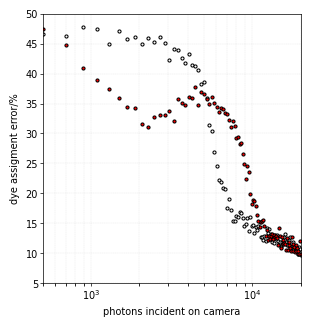

In [17]:
fig, axs = plotter.one_column_plot()

y = (data_0bck_Cy5['dye'].to_numpy() + data_0bck_AF647['dye'].to_numpy())/2
axs = plotter.scatter_plot(axs=axs, x=data_0bck['n_photons'].to_numpy(), y=y*100)

y = (data_4bck_Cy5['dye'].to_numpy() + data_4bck_AF647['dye'].to_numpy())/2
axs = plotter.scatter_plot(axs=axs, x=data_4bck['n_photons'].to_numpy(), y=y*100, facecolor='red', xaxislabel='photons incident on camera',
                          yaxislabel=r'dye assigment error/%')

axs.set_xscale('log')
axs.set_ylim([5, 50])

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250327/fig/multicolour_camera/smoothing/'
file = 'Cy5AF647_Selector.svg'
plt.savefig(os.path.join(folder, file), dpi=600, format='svg')